# NB04 — Ecological Signatures

Test H1 (defense enriched in contaminated habitats) and H2 (metabolism enriched in pristine/REE-impacted habitats). Classify genomes by environment and test for category enrichment.

In [1]:
import sys, os, re, warnings, requests, json, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import fisher_exact, norm
from statsmodels.stats.multitest import fdrcorrection
warnings.filterwarnings("ignore")

spark = get_spark_session()
spark.clearProgressHandlers()
import json as _json
class _SparkSafeEncoder(_json.JSONEncoder):
    def default(self, obj):
        try:
            return super().default(obj)
        except TypeError:
            return str(obj)
_json.JSONEncoder = _SparkSafeEncoder
_json._default_encoder = _SparkSafeEncoder()

from pyspark.sql import functions as F

NOTEBOOK_DIR = Path().resolve()
PROJECT_DIR  = NOTEBOOK_DIR.parent
DATA_DIR     = PROJECT_DIR / "data"
FIG_DIR      = PROJECT_DIR / "figures"
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

def is_valid_parquet(p):
    if not p.exists() or p.stat().st_size < 512:
        return False
    try:
        import pyarrow.parquet as pq; pq.read_schema(str(p)); return True
    except Exception:
        return False

def wilson_ci(n, N, alpha=0.05):
    if N == 0: return np.nan, np.nan
    p = n / N; z = norm.ppf(1 - alpha/2)
    denom = 1 + z**2/N
    centre = (p + z**2/(2*N)) / denom
    half = z * np.sqrt(p*(1-p)/N + z**2/(4*N**2)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)

def odds_ratio_ci(a, b, c, d, alpha=0.05):
    # Woolf logit OR with 95% CI
    a,b,c,d = a+0.5, b+0.5, c+0.5, d+0.5
    log_or = np.log(a*d/(b*c))
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    z = norm.ppf(1 - alpha/2)
    return np.exp(log_or), np.exp(log_or - z*se), np.exp(log_or + z*se)

print("Setup complete.")

Setup complete.


In [2]:
spark.sql('''
    CREATE OR REPLACE TEMP VIEW one_per_species AS
    SELECT species, MIN(genome_id) AS rep_genome_id
    FROM   kbase.ke_pangenome.gtdb_taxonomy_r214v1
    WHERE  species IS NOT NULL
    GROUP BY species
''')
spark.sql('''
    CREATE OR REPLACE TEMP VIEW hq_one_per_species AS
    SELECT t.*
    FROM   kbase.ke_pangenome.gtdb_taxonomy_r214v1 t
    JOIN   one_per_species ops
           ON t.genome_id = ops.rep_genome_id AND t.species = ops.species
''')
n = spark.sql("SELECT COUNT(*) AS n FROM hq_one_per_species").collect()[0]["n"]
print(f"One-per-species set: {n:,} representative genomes")

One-per-species set: 27,690 representative genomes


## Section 1 — Join to NCBI Environment

Map representative genomes to their environments (biome, feature, material).

In [3]:
genome_env_path = DATA_DIR / "genome_env.parquet"
if is_valid_parquet(genome_env_path):
    genome_env_df = pd.read_parquet(genome_env_path)
    print(f"[cache] genome_env: {len(genome_env_df)} genomes")
else:
    # ncbi_env is EAV: accession (BioSample ID), attribute_name, content
    # Must join genome → ncbi_env via ncbi_biosample_id
    genome_env_df = spark.sql('''
        SELECT
            ops.genome_id,
            ops.species,
            ne.content AS isolation_source
        FROM hq_one_per_species ops
        JOIN kbase.ke_pangenome.genome g ON g.genome_id = ops.genome_id
        LEFT JOIN kbase.ke_pangenome.ncbi_env ne
            ON ne.accession = g.ncbi_biosample_id
            AND ne.attribute_name = 'isolation_source'
    ''').toPandas()
    genome_env_df.to_parquet(genome_env_path, index=False)
    print(f"Genome-environment mappings: {len(genome_env_df)} genomes")

print(f"Genomes with isolation_source: {genome_env_df['isolation_source'].notna().sum()}")

Genome-environment mappings: 27690 genomes
Genomes with isolation_source: 15958


## Section 2 — Classify Habitats

Apply regex patterns to classify genomes into habitat types: contaminated, pristine, REE-impacted.

In [4]:
def classify_habitat(env_text):
    if pd.isna(env_text):
        return 'unknown'
    env_text = str(env_text).lower()
    
    contaminated_kw = r'(mine|mining|smelter|tailings|contaminated|industrial|acid mine drainage|heavy metal|polluted|wastewat)'
    ree_kw = r'(rare earth|lanthan|ree|cerium|neodymium)'
    pristine_kw = r'(pristine|uncontaminated|forest|grassland|rhizosphere|ocean|marine|freshwater)'
    
    if re.search(ree_kw, env_text):
        return 'ree_impacted'
    elif re.search(contaminated_kw, env_text):
        return 'contaminated'
    elif re.search(pristine_kw, env_text):
        return 'pristine'
    else:
        return 'other'

genome_env_df['habitat'] = genome_env_df['isolation_source'].apply(classify_habitat)

print("Habitat classification distribution:")
print(genome_env_df['habitat'].value_counts())

Habitat classification distribution:
habitat
other           13300
unknown         11732
pristine         1530
contaminated     1014
ree_impacted      114
Name: count, dtype: int64


## Section 3 — Merge with Metal Gene Counts and Test Enrichment

Join habitat classification with metal gene counts and test for enrichment by habitat.

In [5]:
# Load metal gene counts
genome_counts = pd.read_parquet(DATA_DIR / "genome_metal_counts.parquet")

# Merge with habitat classification
ecology_df = genome_env_df[['genome_id', 'habitat']].merge(
    genome_counts[['genome_id', 'n_defense', 'n_metabolism', 'n_homeostasis']],
    on='genome_id', how='inner')

print(f"Genomes with both habitat and metal gene data: {len(ecology_df)}")

# Test enrichment: Fisher's exact for each category × habitat
categories = ['defense', 'metabolism', 'homeostasis']
habitats = ['contaminated', 'pristine', 'ree_impacted']

ecology_results = []
pvalues = []

for habitat in habitats:
    habitat_data = ecology_df[ecology_df['habitat'] == habitat]
    rest_data = ecology_df[ecology_df['habitat'] != habitat]
    
    if len(habitat_data) > 0 and len(rest_data) > 0:
        for category in categories:
            col = f"n_{category}"
            
            habitat_has = (habitat_data[col] > 0).sum()
            habitat_not = (habitat_data[col] == 0).sum()
            rest_has = (rest_data[col] > 0).sum()
            rest_not = (rest_data[col] == 0).sum()
            
            if habitat_has + habitat_not > 0 and rest_has + rest_not > 0:
                oddsratio, pval = fisher_exact([[habitat_has, habitat_not], [rest_has, rest_not]], alternative='two-sided')
                or_est, or_ci_low, or_ci_high = odds_ratio_ci(habitat_has, habitat_not, rest_has, rest_not)
                
                ecology_results.append({
                    'habitat': habitat,
                    'category': category,
                    'habitat_has': habitat_has,
                    'habitat_not': habitat_not,
                    'rest_has': rest_has,
                    'rest_not': rest_not,
                    'odds_ratio': or_est,
                    'or_ci_low': or_ci_low,
                    'or_ci_high': or_ci_high,
                    'p_value': pval
                })
                pvalues.append(pval)

ecology_results_df = pd.DataFrame(ecology_results)

# BH-FDR correction — fdrcorrection returns (reject, corrected_pvalues)
if len(pvalues) > 0:
    reject, q_values = fdrcorrection(ecology_results_df['p_value'].values, alpha=0.05)
    ecology_results_df['q_value'] = q_values
    ecology_results_df['significant'] = reject
    
    ecology_results_df.to_csv(DATA_DIR / "ecology_results.csv", index=False)
    
    print("\nSignificant enrichments (q < 0.05):")
    sig = ecology_results_df[ecology_results_df['significant']]
    if len(sig) > 0:
        print(sig[['habitat', 'category', 'odds_ratio', 'or_ci_low', 'or_ci_high', 'q_value']])
    else:
        print("None")

Genomes with both habitat and metal gene data: 27690

Significant enrichments (q < 0.05):
        habitat     category  odds_ratio  or_ci_low  or_ci_high       q_value
0  contaminated      defense    0.323093   0.231030    0.451841  4.574293e-08
1  contaminated   metabolism    1.250999   1.101248    1.421113  1.764120e-03
2  contaminated  homeostasis    0.501577   0.426394    0.590017  8.225093e-14
5      pristine  homeostasis    0.822916   0.703960    0.961973  3.078436e-02
8  ree_impacted  homeostasis    3.826946   1.319724   11.097405  4.866668e-03


## Section 3b — Phylum-Adjusted Logistic Regression

Fisher's exact tests above cannot separate ecological signal from taxonomic composition bias (contaminated habitats are enriched in defense-poor archaea). This section re-tests each habitat × category association using logistic regression with phylum included as a covariate, isolating the habitat effect after controlling for phylum composition.

In [6]:
import statsmodels.formula.api as smf

# Merge phylum into ecology_df
genome_counts_full = pd.read_parquet(DATA_DIR / "genome_metal_counts.parquet")
ecology_phylum = ecology_df.merge(
    genome_counts_full[['genome_id', 'phylum']],
    on='genome_id', how='inner'
)
# Exclude unknowns — only genomes with a classified habitat
ecology_phylum = ecology_phylum[ecology_phylum['habitat'] != 'unknown'].copy()

# Group rare phyla into 'Other' to avoid perfect separation
TOP_PHYLA = ecology_phylum['phylum'].value_counts().nlargest(10).index.tolist()
ecology_phylum['phylum_grp'] = ecology_phylum['phylum'].where(
    ecology_phylum['phylum'].isin(TOP_PHYLA), 'Other'
)

logit_rows = []
for habitat in ['contaminated', 'pristine', 'ree_impacted']:
    df = ecology_phylum.copy()
    df['is_habitat'] = (df['habitat'] == habitat).astype(int)

    for category in ['defense', 'metabolism', 'homeostasis']:
        df['has_cat'] = (df[f'n_{category}'] > 0).astype(int)
        try:
            model = smf.logit('has_cat ~ is_habitat + C(phylum_grp)', data=df).fit(disp=0)
            coef   = model.params['is_habitat']
            pval   = model.pvalues['is_habitat']
            ci     = model.conf_int().loc['is_habitat']
            logit_rows.append({
                'habitat': habitat, 'category': category,
                'or_phylum_adj': round(np.exp(coef), 3),
                'or_ci_low': round(np.exp(ci[0]), 3),
                'or_ci_high': round(np.exp(ci[1]), 3),
                'p_value': pval,
            })
        except Exception as e:
            logit_rows.append({'habitat': habitat, 'category': category, 'or_phylum_adj': None, 'p_value': None, 'note': str(e)})

logit_df = pd.DataFrame(logit_rows)
valid = logit_df['p_value'].notna()
if valid.any():
    _, logit_df.loc[valid, 'q_value'] = fdrcorrection(logit_df.loc[valid, 'p_value'].values, alpha=0.05)
    logit_df['significant'] = logit_df['q_value'] < 0.05

logit_df.to_csv(DATA_DIR / "ecology_results_phylum_adj.csv", index=False)

# Compare raw Fisher OR vs phylum-adjusted OR side by side
compare = ecology_results_df[['habitat','category','odds_ratio','q_value']].rename(
    columns={'odds_ratio': 'or_raw', 'q_value': 'q_raw'}).merge(
    logit_df[['habitat','category','or_phylum_adj','q_value']].rename(columns={'q_value': 'q_adj'}),
    on=['habitat','category'], how='outer'
)
compare['direction_change'] = compare.apply(
    lambda r: 'reverses' if (r.or_raw > 1) != (r.or_phylum_adj > 1)
              else 'attenuates' if abs(r.or_phylum_adj - 1) < abs(r.or_raw - 1) * 0.5
              else 'robust', axis=1)

print("Raw Fisher OR vs Phylum-Adjusted OR:")
print(compare[['habitat','category','or_raw','q_raw','or_phylum_adj','q_adj','direction_change']].to_string(index=False))


/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Raw Fisher OR vs Phylum-Adjusted OR:
     habitat    category   or_raw        q_raw  or_phylum_adj        q_adj direction_change
contaminated     defense 0.323093 4.574293e-08          0.637 2.170982e-02           robust
contaminated homeostasis 0.501577 8.225093e-14          0.654 6.316921e-05           robust
contaminated  metabolism 1.250999 1.764120e-03          1.279 1.561271e-03           robust
    pristine     defense 0.786582 3.347154e-01            NaN          NaN           robust
    pristine homeostasis 0.822916 3.078436e-02          0.595 1.689469e-07           robust
    pristine  metabolism 0.995267 9.369185e-01          0.702 2.343004e-08           robust
ree_impacted     defense 3.229503 4.650438e-01            NaN          NaN         reverses
ree_impacted homeostasis 3.826946 4.866668e-03          2.760 1.123582e-01           robust
ree_impacted  metabolism 1.457424 8.883680e-02          1.237 3.125362e-01           robust


## Section 4 — Violin Plots

Visualize gene count distributions across habitat types.

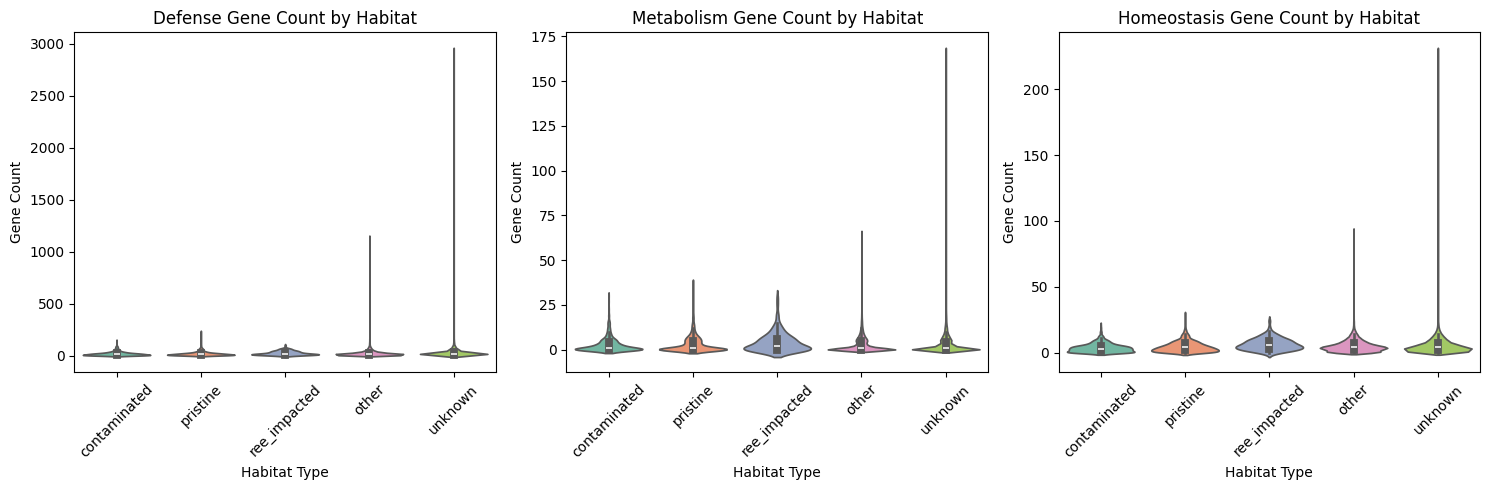

Figure saved: nb04_habitat_violin.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, category in enumerate(['defense', 'metabolism', 'homeostasis']):
    ax = axes[i]
    col = f"n_{category}"
    
    # Filter to genomes with habitat data
    plot_data = ecology_df[[col, 'habitat']].copy()
    plot_data.columns = ['count', 'habitat']
    
    # Reorder habitats
    habitat_order = ['contaminated', 'pristine', 'ree_impacted', 'other', 'unknown']
    plot_data['habitat'] = pd.Categorical(plot_data['habitat'], categories=habitat_order, ordered=True)
    plot_data = plot_data.dropna(subset=['habitat']).sort_values('habitat')
    
    sns.violinplot(data=plot_data, x='habitat', y='count', ax=ax, palette='Set2')
    ax.set_title(f"{category.capitalize()} Gene Count by Habitat")
    ax.set_xlabel('Habitat Type')
    ax.set_ylabel('Gene Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / "nb04_habitat_violin.png", dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: nb04_habitat_violin.png")